LightGBM: gradient boosting like XGBoost, but grows trees **leaf-wise** (split the leaf that reduces loss the most) instead of **level-wise** (split every leaf at the current depth). Faster on large data. Requires `pip install lightgbm` (already installed here).

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb
import xgboost as xgb

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("lightgbm version:", lgb.__version__)

lightgbm version: 4.6.0


In [2]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
)
lgb_clf.fit(X_train, y_train)

y_pred = lgb_clf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 95.32%
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        64
      benign       0.95      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: U

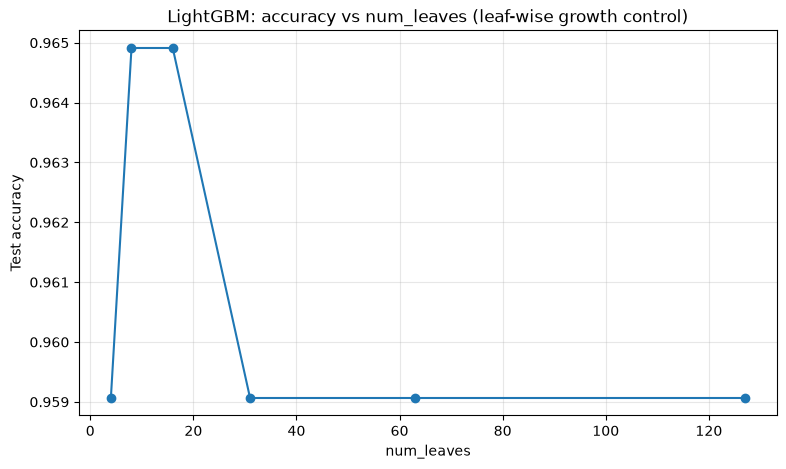

In [3]:
# Leaf-wise vs level-wise: LightGBM's num_leaves controls tree complexity directly,
# instead of max_depth like most level-wise growers.
num_leaves_range = [4, 8, 16, 31, 63, 127]
accs = []
for nl in num_leaves_range:
    m = lgb.LGBMClassifier(n_estimators=200, num_leaves=nl, random_state=42, verbose=-1)
    m.fit(X_train, y_train)
    accs.append(m.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(num_leaves_range, accs, 'o-')
plt.xlabel('num_leaves')
plt.ylabel('Test accuracy')
plt.title('LightGBM: accuracy vs num_leaves (leaf-wise growth control)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Speed comparison: LightGBM's histogram-based splitting is built for speed at scale.
# Even on this small dataset, time both fairly across several runs.
def time_fit(model, X, y, n=5):
    times = []
    for _ in range(n):
        t0 = time.time()
        model.fit(X, y)
        times.append(time.time() - t0)
    return np.mean(times)

lgb_time = time_fit(lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1), X_train, y_train)
xgb_time = time_fit(xgb.XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss'), X_train, y_train)

print(f"LightGBM avg fit time: {lgb_time:.4f}s")
print(f"XGBoost avg fit time:  {xgb_time:.4f}s")
print("\n(On small datasets the gap is minor -- LightGBM's histogram binning pays off most on large/wide data.)")

LightGBM avg fit time: 0.0231s
XGBoost avg fit time:  0.0380s

(On small datasets the gap is minor -- LightGBM's histogram binning pays off most on large/wide data.)


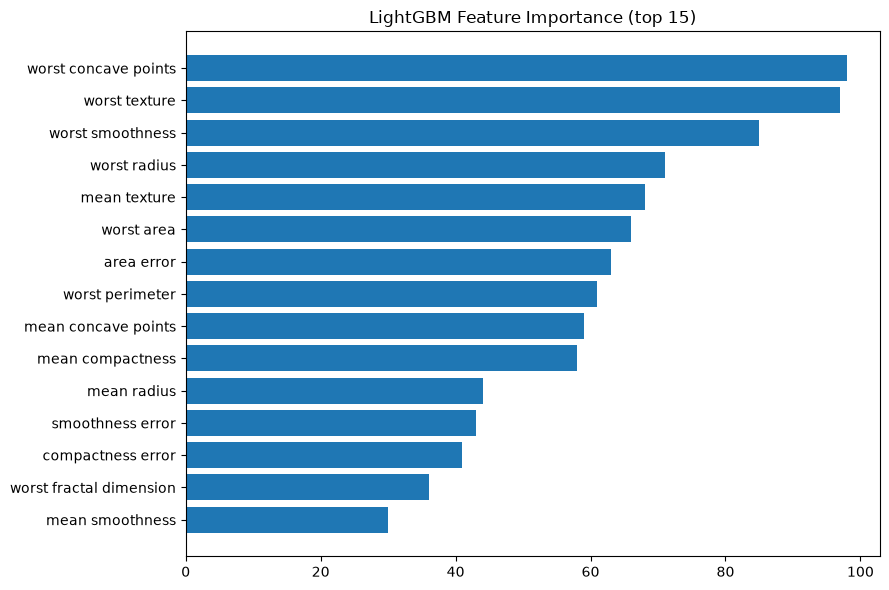

In [5]:
# Feature importance
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title('LightGBM Feature Importance (top 15)')
plt.tight_layout()
plt.show()

C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: U

C:\Users\nitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


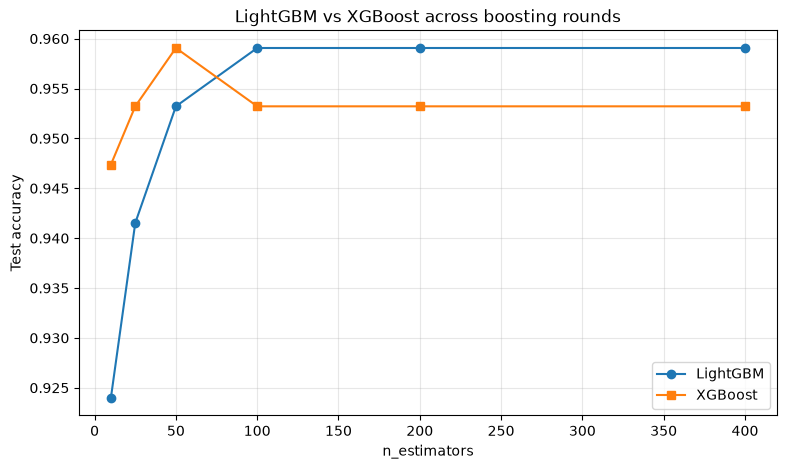

In [6]:
# Accuracy comparison across boosting rounds (n_estimators)
n_est_range = [10, 25, 50, 100, 200, 400]
lgb_accs, xgb_accs = [], []
for n in n_est_range:
    lm = lgb.LGBMClassifier(n_estimators=n, random_state=42, verbose=-1).fit(X_train, y_train)
    xm = xgb.XGBClassifier(n_estimators=n, random_state=42, eval_metric='logloss').fit(X_train, y_train)
    lgb_accs.append(lm.score(X_test, y_test))
    xgb_accs.append(xm.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(n_est_range, lgb_accs, 'o-', label='LightGBM')
plt.plot(n_est_range, xgb_accs, 's-', label='XGBoost')
plt.xlabel('n_estimators')
plt.ylabel('Test accuracy')
plt.title('LightGBM vs XGBoost across boosting rounds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()